# Evaluación del modelo de predicción de Binding Sites
Compara los residuos predichos por el modelo Random Forest con los residuos reales del binding site (PDBbind) para 21 proteínas no vistas durante el entrenamiento.

**Inputs por proteína:**
- `{pdb_id}_pocket.pdb` → residuos reales del binding site (PDBbind)
- `{pdb_id}_protein_binding_site_residues.txt` → residuos predichos por el modelo

**Outputs:**
- Métricas por proteína: Accuracy, Precision, Recall, F1, ROC-AUC, MCC
- Métricas globales agregadas
- Matriz de confusión global
- Gráficas de comparación

## 0. Imports y configuración

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from Bio.PDB import PDBParser
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay
)

# ── Ajusta estas rutas a tu estructura de carpetas ──────────────────────────
CARPETA_POCKETS   = "pockets/"          # carpeta con los {pdb_id}_pocket.pdb
CARPETA_PREDICHOS = "predictions/"      # carpeta con los {pdb_id}_protein_binding_site_residues.txt
CARPETA_PROTEINS  = "proteins/"         # carpeta con los {pdb_id}_protein.pdb (proteína completa)

# Lista de los 20 PDB IDs a evaluar
PDB_IDS = ['5e7n', '3s1h', '2y7x', '5jm4', '4ehg', '4c1g', '4b12', '3ti5', '5jcj', '3rf5', '5fqb', '5jm4', '5vqu', '4x6i', '3qs4', '4zam', '4o2a', '2ydj', '2yc5', '3qzt', '4awi']

print(f"Proteínas a evaluar: {len(PDB_IDS)}")

Proteínas a evaluar: 4


## 1. Funciones de parseo

In [4]:
def parsear_pocket_pdb(pocket_pdb_path):
    """
    Lee un fichero _pocket.pdb de PDBbind y devuelve un set de tuplas
    (chain_id, res_seq) con los residuos reales del binding site.
    Ignora líneas HETATM (aguas, etc.).
    """
    residuos_reales = set()
    with open(pocket_pdb_path, 'r') as f:
        for linea in f:
            if linea.startswith('ATOM'):
                chain  = linea[21].strip()        # columna 22
                res_id = int(linea[22:26].strip()) # columnas 23-26
                residuos_reales.add((chain, res_id))
    return residuos_reales


def parsear_predichos_txt(predichos_txt_path):
    """
    Lee el fichero _binding_site_residues.txt generado por predict_binding_site.py
    y devuelve un set de tuplas (chain_id, res_seq).
    """
    residuos_predichos = set()
    with open(predichos_txt_path, 'r') as f:
        for linea in f:
            linea = linea.strip()
            # Saltamos cabeceras
            if (not linea or linea.startswith('Binding') or
                linea.startswith('Total') or linea.startswith('=') or
                linea.startswith('-') or linea.startswith('Chain')):
                continue
            partes = linea.split()
            if len(partes) >= 2:
                chain  = partes[0]
                res_id = int(partes[1])
                residuos_predichos.add((chain, res_id))
    return residuos_predichos


def obtener_todos_residuos_proteina(protein_pdb_path):
    """
    Lee la proteína completa y devuelve el set de todos sus residuos
    (chain, res_id). Esto es necesario para calcular los True Negatives:
    residuos que no están en el pocket real NI en la predicción.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", protein_pdb_path)
    todos = set()
    for model in structure:
        for chain in model:
            for residuo in chain:
                if residuo.get_id()[0] == ' ':  # solo ATOM, no HETATM
                    todos.add((chain.get_id(), residuo.get_id()[1]))
    return todos


print("Funciones de parseo definidas.")

Funciones de parseo definidas.


## 2. Función de métricas por proteína

In [5]:
def calcular_metricas(reales, predichos, todos_residuos):
    """
    Dado el set de residuos reales, predichos y todos los residuos de la proteína,
    construye vectores y_true / y_pred a nivel de residuo y calcula métricas.

    Lógica:
      - Un residuo es positivo (1) si está en el pocket real
      - Un residuo es predicho como positivo si está en predichos
      - TP: real=1, pred=1
      - FP: real=0, pred=1
      - FN: real=1, pred=0
      - TN: real=0, pred=0
    """
    y_true = []
    y_pred = []

    for residuo in todos_residuos:
        y_true.append(1 if residuo in reales    else 0)
        y_pred.append(1 if residuo in predichos else 0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metricas = {
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
        # ROC-AUC y PR-AUC: usamos y_pred como score (binario)
        'roc_auc':   roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'pr_auc':    average_precision_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float('nan'),
        'n_reales':    int(len(reales)),
        'n_predichos': int(len(predichos)),
        'n_total':     int(len(todos_residuos)),
    }
    return metricas, y_true, y_pred


print("Función de métricas definida.")

Función de métricas definida.


## 3. Evaluar las 21 proteínas

In [34]:
resultados     = []   # métricas por proteína
y_true_global  = []   # para la matriz de confusión global
y_pred_global  = []
errores        = []   # proteínas que no se pudieron procesar

for pdb_id in PDB_IDS:
    pocket_path  = os.path.join(CARPETA_POCKETS,   f"{pdb_id}_pocket.pdb")
    pred_path    = os.path.join(CARPETA_PREDICHOS, f"{pdb_id}_protein_binding_site_residues.txt")
    protein_path = os.path.join(CARPETA_PROTEINS,  f"{pdb_id}_protein.pdb")

    # Verificar que existen los tres ficheros
    faltantes = [p for p in [pocket_path, pred_path, protein_path] if not os.path.exists(p)]
    if faltantes:
        print(f"[SKIP] {pdb_id}: faltan ficheros → {faltantes}")
        errores.append(pdb_id)
        continue

    try:
        reales          = parsear_pocket_pdb(pocket_path)
        predichos       = parsear_predichos_txt(pred_path)
        todos_residuos  = obtener_todos_residuos_proteina(protein_path)

        metricas, y_t, y_p = calcular_metricas(reales, predichos, todos_residuos)
        metricas['pdb_id'] = pdb_id
        resultados.append(metricas)

        y_true_global.extend(y_t)
        y_pred_global.extend(y_p)

        print(f"[OK] {pdb_id:8s} | Reales: {metricas['n_reales']:4d} | "
              f"Predichos: {metricas['n_predichos']:4d} | "
              f"Recall: {metricas['recall']:.3f} | "
              f"Precision: {metricas['precision']:.3f} | "
              f"MCC: {metricas['mcc']:.3f}")

    except Exception as e:
        print(f"[ERROR] {pdb_id}: {e}")
        errores.append(pdb_id)

print(f"\nProteínas procesadas: {len(resultados)} / {len(PDB_IDS)}")
if errores:
    print(f"Con errores: {errores}")

[OK] 5e7n     | Reales:   49 | Predichos:   11 | Recall: 0.204 | Precision: 0.909 | MCC: 0.327
[OK] 3s1h     | Reales:   78 | Predichos:  103 | Recall: 0.551 | Precision: 0.417 | MCC: 0.257
[OK] 2y7x     | Reales:   80 | Predichos:   86 | Recall: 0.375 | Precision: 0.349 | MCC: 0.094
[OK] 5jm4     | Reales:  104 | Predichos:  103 | Recall: 0.317 | Precision: 0.320 | MCC: 0.121

Proteínas procesadas: 4 / 4


## 4. Tabla de resultados por proteína

In [35]:
df_res = pd.DataFrame(resultados).set_index('pdb_id')

# Columnas a mostrar
cols_display = ['n_reales', 'n_predichos', 'TP', 'FP', 'FN', 'TN',
                'accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']

df_display = df_res[cols_display].copy()

# Formatear decimales solo en columnas de métricas
metricas_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']
df_display[metricas_cols] = df_display[metricas_cols].round(3)

print("Resultados por proteína:")
display(df_display)

Resultados por proteína:


,n_reales,n_predichos,TP,FP,FN,TN,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
pdb_id,,,,,,,,,,,,,
5e7n,49,11,10,1,39,73,0.675,0.909,0.204,0.333,0.327,0.595,0.503
3s1h,78,103,43,60,35,160,0.681,0.417,0.551,0.475,0.257,0.639,0.348
2y7x,80,86,30,56,50,145,0.623,0.349,0.375,0.361,0.094,0.548,0.309
5jm4,104,103,33,70,71,285,0.693,0.320,0.317,0.319,0.121,0.560,0.256


## 5. Métricas globales agregadas

In [36]:
y_true_global = np.array(y_true_global)
y_pred_global = np.array(y_pred_global)

print("="*50)
print("MÉTRICAS GLOBALES (todas las proteínas)")
print("="*50)
print(f"Total residuos evaluados : {len(y_true_global):,}")
print(f"Total positivos reales   : {y_true_global.sum():,}")
print(f"Total positivos predichos: {y_pred_global.sum():,}")
print()
print(classification_report(y_true_global, y_pred_global,
                            target_names=['No binding (0)', 'Binding (1)']))

mcc_global = matthews_corrcoef(y_true_global, y_pred_global)
roc_global = roc_auc_score(y_true_global, y_pred_global)
pr_global  = average_precision_score(y_true_global, y_pred_global)

print(f"MCC global   : {mcc_global:.4f}")
print(f"ROC-AUC global: {roc_global:.4f}")
print(f"PR-AUC global : {pr_global:.4f}")

print("\nMedia y desviación estándar por proteína:")
display(df_res[metricas_cols].agg(['mean', 'std']).round(3))

MÉTRICAS GLOBALES (todas las proteínas)
Total residuos evaluados : 1,161
Total positivos reales   : 311
Total positivos predichos: 303

                precision    recall  f1-score   support

No binding (0)       0.77      0.78      0.78       850
   Binding (1)       0.38      0.37      0.38       311

      accuracy                           0.67      1161
     macro avg       0.58      0.58      0.58      1161
  weighted avg       0.67      0.67      0.67      1161

MCC global   : 0.1543
ROC-AUC global: 0.5765
PR-AUC global : 0.3108

Media y desviación estándar por proteína:


,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc
mean,0.668,0.499,0.362,0.372,0.200,0.586,0.354
std,0.031,0.276,0.145,0.071,0.111,0.041,0.106


## 6. Matriz de confusión global

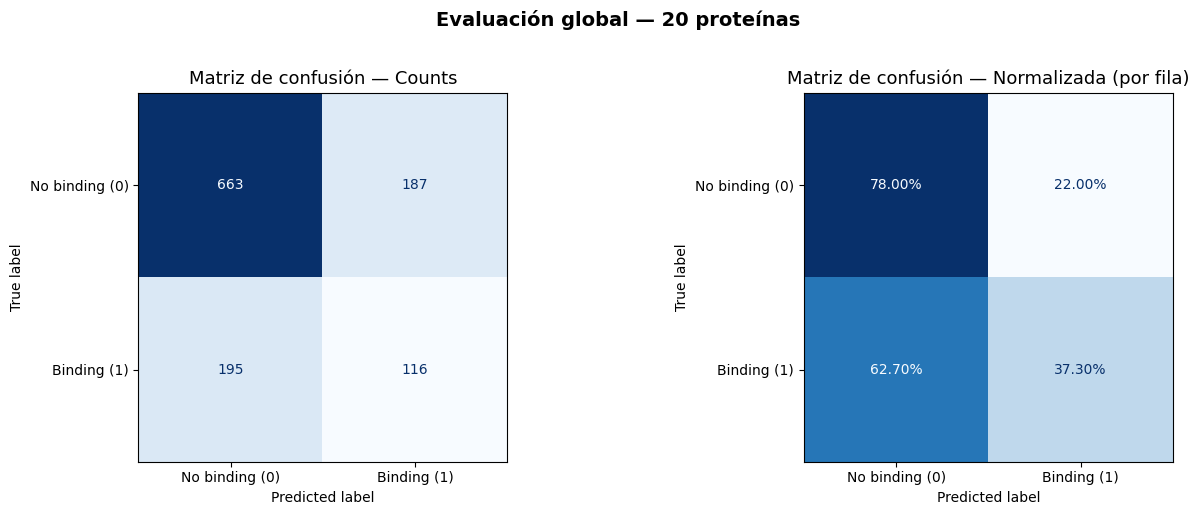

TP=116  FP=187  FN=195  TN=663


In [37]:
cm_global = confusion_matrix(y_true_global, y_pred_global, labels=[0, 1])
tn, fp, fn, tp = cm_global.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Counts ──
disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_global,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_counts.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Counts', fontsize=13)

# ── Porcentajes (normalizada por fila) ──
cm_norm = cm_global.astype(float) / cm_global.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['No binding (0)', 'Binding (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de confusión — Normalizada (por fila)', fontsize=13)

plt.suptitle('Evaluación global — 20 proteínas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")

## 7. Distribución de métricas entre proteínas

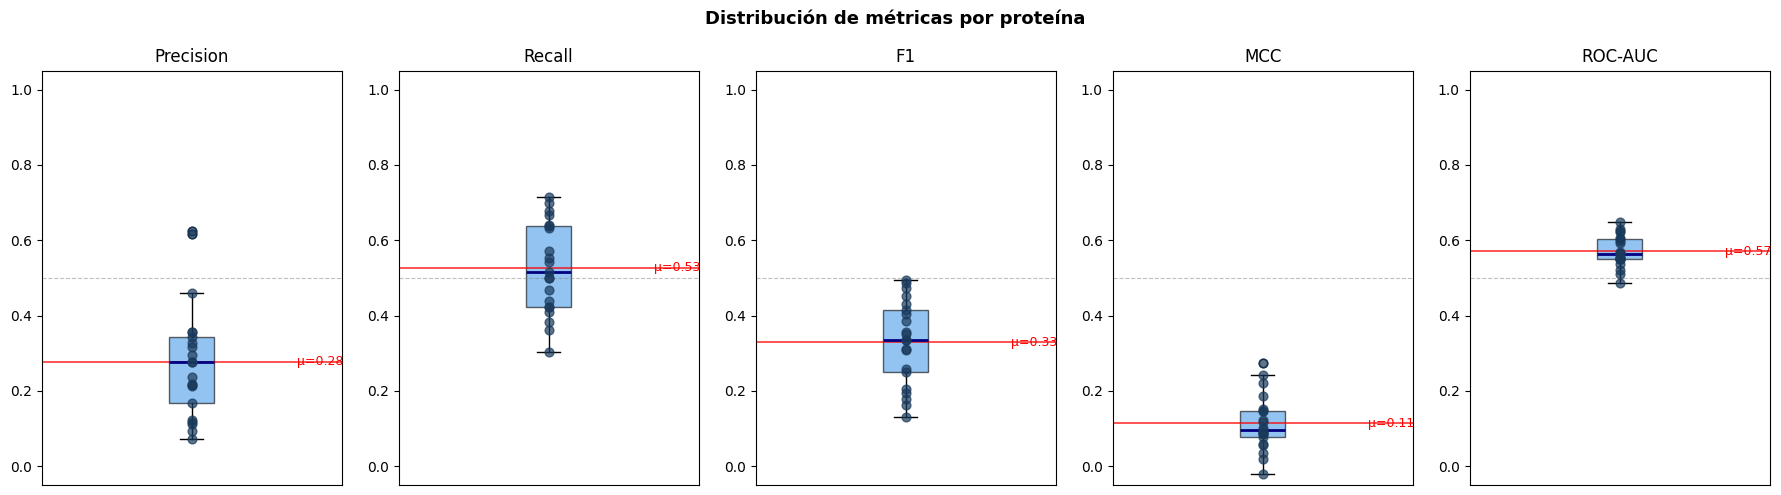

In [10]:
metricas_plot = ['precision', 'recall', 'f1', 'mcc', 'roc_auc']
labels_plot   = ['Precision', 'Recall', 'F1', 'MCC', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metricas_plot), figsize=(18, 5))

for ax, col, label in zip(axes, metricas_plot, labels_plot):
    valores = df_res[col].dropna()
    ax.boxplot(valores, patch_artist=True,
               boxprops=dict(facecolor='#4C9BE8', alpha=0.6),
               medianprops=dict(color='navy', linewidth=2))
    ax.scatter([1]*len(valores), valores,
               color='#1a3a5c', alpha=0.7, zorder=5, s=40)
    ax.set_title(label, fontsize=12)
    ax.set_xticks([])
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    media = valores.mean()
    ax.axhline(media, color='red', linestyle='-', linewidth=1.2, alpha=0.8)
    ax.text(1.35, media, f'μ={media:.2f}', va='center', fontsize=9, color='red')

plt.suptitle('Distribución de métricas por proteína', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metricas_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap de métricas por proteína

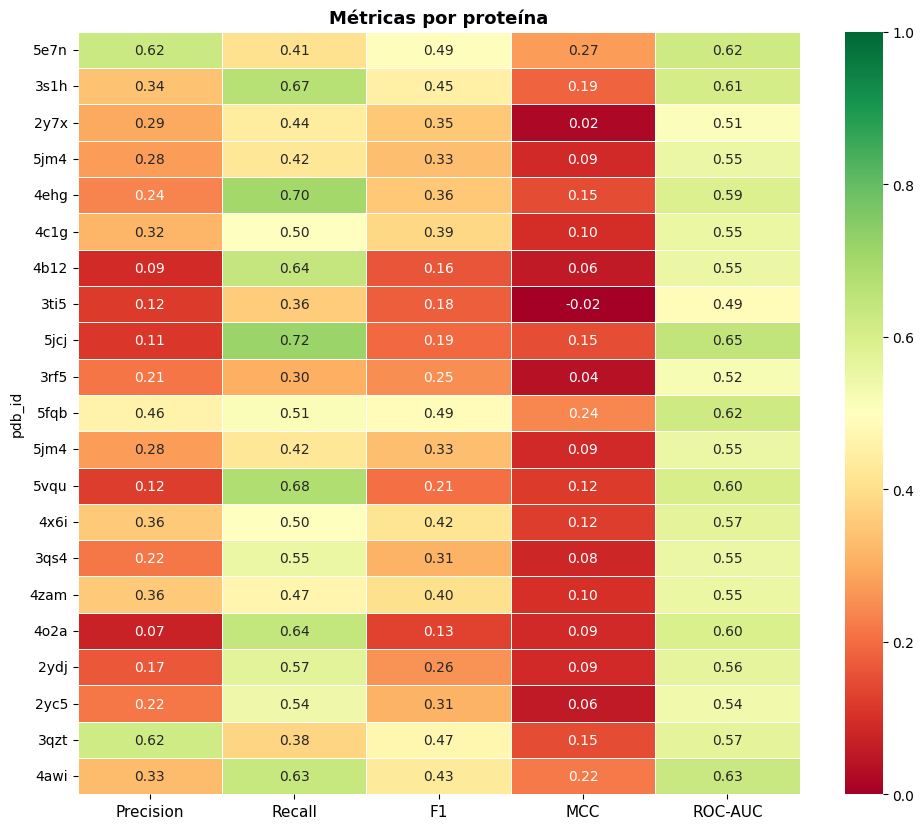

In [11]:
df_heat = df_res[metricas_plot].copy()

fig, ax = plt.subplots(figsize=(10, max(6, len(df_heat) * 0.4)))
sns.heatmap(
    df_heat,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Métricas por proteína', fontsize=13, fontweight='bold')
ax.set_xticklabels(labels_plot, fontsize=11)
ax.set_yticklabels(df_heat.index, rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('heatmap_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Precision vs Recall por proteína

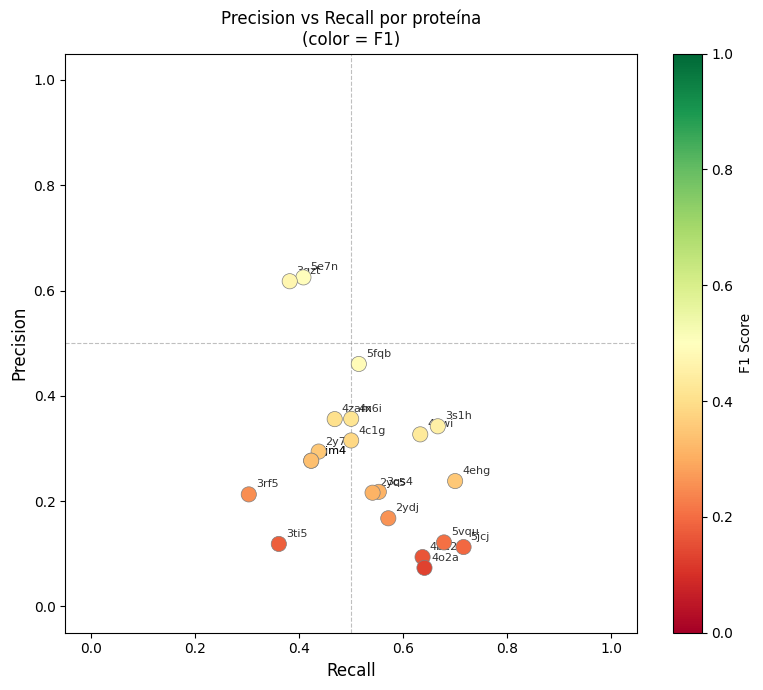

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    df_res['recall'], df_res['precision'],
    c=df_res['f1'], cmap='RdYlGn',
    s=120, edgecolors='gray', linewidths=0.5,
    vmin=0, vmax=1, zorder=5
)

# Etiquetar cada punto con el pdb_id
for pdb_id, row in df_res.iterrows():
    ax.annotate(pdb_id,
                xy=(row['recall'], row['precision']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

# Líneas de referencia
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.colorbar(scatter, ax=ax, label='F1 Score')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision vs Recall por proteína\n(color = F1)', fontsize=12)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Guardar resultados en CSV

In [ ]:
df_res.to_csv('resultados_evaluacion.csv')
print("Resultados guardados en: resultados_evaluacion.csv")

# Resumen ejecutivo
print("\n" + "="*50)
print("RESUMEN EJECUTIVO")
print("="*50)
print(f"Proteínas evaluadas : {len(df_res)}")
print(f"Recall medio        : {df_res['recall'].mean():.3f} ± {df_res['recall'].std():.3f}")
print(f"Precision media     : {df_res['precision'].mean():.3f} ± {df_res['precision'].std():.3f}")
print(f"F1 medio            : {df_res['f1'].mean():.3f} ± {df_res['f1'].std():.3f}")
print(f"MCC medio           : {df_res['mcc'].mean():.3f} ± {df_res['mcc'].std():.3f}")
print(f"ROC-AUC global      : {roc_global:.4f}")
print(f"PR-AUC global       : {pr_global:.4f}")
print()
print("Mejor proteína (F1):")
print(df_res.loc[df_res['f1'].idxmax(), ['precision', 'recall', 'f1', 'mcc']].round(3))
print()
print("Peor proteína (F1):")
print(df_res.loc[df_res['f1'].idxmin(), ['precision', 'recall', 'f1', 'mcc']].round(3))